In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
DATA_PATH = r'D:\VoiceIQ\data\processed\voiceiq_features_1000.csv'

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)

Shape: (1000, 53)


In [3]:
df.head()

,duration,rms_mean,rms_std,rms_min,rms_max,rms_median,zcr_mean,zcr_std,zcr_min,zcr_max,...,mfcc_13_mean,mfcc_13_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_median,sample_id,system_id,mos
0,6.149125,0.173858,0.054850,0.075963,0.398496,0.164070,0.228194,0.104719,0.044922,0.494629,...,-19.662941,7.825193,1094.502439,881.983948,192.630595,2033.420746,314.742105,urgent25_blind_test_fileid_000001,urgent25_blind_test_submission_716,1.500
1,5.666062,0.098440,0.050911,0.019863,0.202346,0.100245,0.184403,0.110771,0.041016,0.612305,...,-7.641559,6.461961,203.667094,54.936994,91.436169,320.243700,199.423698,urgent25_blind_test_fileid_000002,urgent25_blind_test_submission_716,2.125
2,3.627000,0.086625,0.047802,0.020838,0.204252,0.080475,0.130320,0.124145,0.011230,0.585938,...,-3.789234,6.191098,197.237511,56.709864,101.454781,290.291740,202.345478,urgent25_blind_test_fileid_000003,urgent25_blind_test_submission_716,3.750
3,3.460437,0.117501,0.082194,0.000371,0.296434,0.124968,0.053671,0.035271,0.008301,0.189453,...,-4.772955,8.028147,211.423097,46.373234,98.566561,316.565388,211.282048,urgent25_blind_test_fileid_000004,urgent25_blind_test_submission_716,1.625
4,3.664563,0.073171,0.043997,0.007853,0.181572,0.077773,0.105206,0.082447,0.039551,0.522949,...,-7.895499,6.907146,123.681352,28.796260,72.993346,189.321316,126.356819,urgent25_blind_test_fileid_000005,urgent25_blind_test_submission_716,3.625


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   duration                 1000 non-null   float64
 1   rms_mean                 1000 non-null   float64
 2   rms_std                  1000 non-null   float64
 3   rms_min                  1000 non-null   float64
 4   rms_max                  1000 non-null   float64
 5   rms_median               1000 non-null   float64
 6   zcr_mean                 1000 non-null   float64
 7   zcr_std                  1000 non-null   float64
 8   zcr_min                  1000 non-null   float64
 9   zcr_max                  1000 non-null   float64
 10  zcr_median               1000 non-null   float64
 11  spectral_centroid_mean   1000 non-null   float64
 12  spectral_centroid_std    1000 non-null   float64
 13  spectral_bandwidth_mean  1000 non-null   float64
 14  spectral_bandwidth_std   1000 non-nu

In [5]:
df.describe()

,duration,rms_mean,rms_std,rms_min,rms_max,rms_median,zcr_mean,zcr_std,zcr_min,zcr_max,...,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,pitch_mean,pitch_std,pitch_min,pitch_max,pitch_median,mos
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,994.000000,994.000000,994.000000,994.000000,994.000000,1000.000000
mean,6.450151,0.094750,0.059312,0.012037,0.256492,0.086552,0.119354,0.070871,0.023808,0.379894,...,1.431073,7.915002,-4.322707,7.627707,201.737295,71.744012,106.087241,360.833824,191.443397,2.027375
std,2.987198,0.042289,0.026708,0.017651,0.095278,0.048666,0.059053,0.040883,0.022602,0.186599,...,6.947365,2.565674,5.759204,2.554465,182.969821,120.712527,127.393127,395.350063,187.760812,0.739151
min,3.000000,0.008839,0.005232,0.000000,0.038722,0.000132,0.015959,0.007541,0.000000,0.055176,...,-18.364252,3.077160,-23.468021,3.030431,65.406391,0.000000,65.406391,65.406391,65.406391,1.000000
25%,4.248703,0.067453,0.042219,0.000060,0.198800,0.052462,0.075884,0.037908,0.006836,0.223022,...,-2.757192,6.290381,-7.995353,5.975328,117.958649,21.354124,65.406391,175.625645,114.623209,1.500000
50%,5.691125,0.091721,0.057043,0.004009,0.260423,0.081666,0.108001,0.064886,0.021484,0.365479,...,1.294985,7.479237,-4.335130,7.183363,160.389634,36.312709,71.326176,245.519371,156.464662,1.875000
75%,7.632828,0.116969,0.072165,0.017996,0.309623,0.112687,0.148801,0.097165,0.033691,0.517944,...,5.418319,9.004731,-0.761383,8.722605,216.527686,63.565454,106.252996,332.977501,214.206703,2.500000
max,19.880000,0.372463,0.221027,0.109960,0.712582,0.461827,0.447043,0.314464,0.203125,0.934082,...,36.110138,24.716465,29.563377,23.114204,1922.978589,881.983948,1811.571936,2093.004522,2045.200233,4.625000


In [6]:
print('MOS missing values:', df['mos'].isna().sum())
print('MOS mean:', df['mos'].mean())
print('MOS std:',df['mos'].std())
print('MOS minimum:',df['mos'].min())
print('MOS maximum:',df['mos'].max())

MOS missing values: 0
MOS mean: 2.027375
MOS std: 0.739150747955519
MOS minimum: 1.0
MOS maximum: 4.625


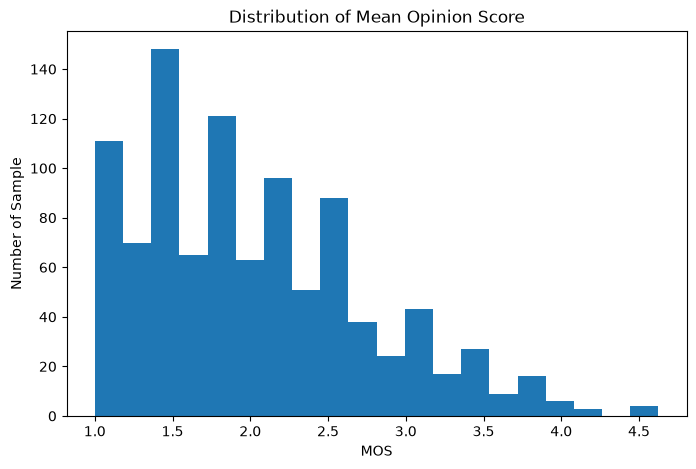

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['mos'],bins=20)

plt.xlabel('MOS')
plt.ylabel('Number of Sample')
plt.title('Distribution of Mean Opinion Score')
plt.show()

In [8]:
metadata_column = [
    'sample_id',
    'system_id'
]

target_column = 'mos'

feature_column = [
    column
    for column in df.columns
    if column not in metadata_column + [target_column]
]
print('Numbeer of feature:', len(feature_column))
print('\nFeatures:')
print(feature_column)

Numbeer of feature: 50

Features:
['duration', 'rms_mean', 'rms_std', 'rms_min', 'rms_max', 'rms_median', 'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'zcr_median', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_bandwidth_mean', 'spectral_bandwidth_std', 'spectral_rolloff_mean', 'spectral_rolloff_std', 'spectral_contrast_mean', 'spectral_contrast_std', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'pitch_mean', 'pitch_std', 'pitch_min', 'pitch_max', 'pitch_median']


In [9]:
X = df[feature_column]
y = df[target_column]

print('X shape:',X.shape)
print('y shape:',y.shape)

X shape: (1000, 50)
y shape: (1000,)


In [10]:
X.dtypes

duration                   float64
rms_mean                   float64
rms_std                    float64
rms_min                    float64
rms_max                    float64
rms_median                 float64
zcr_mean                   float64
zcr_std                    float64
zcr_min                    float64
zcr_max                    float64
zcr_median                 float64
spectral_centroid_mean     float64
spectral_centroid_std      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_std     float64
spectral_rolloff_mean      float64
spectral_rolloff_std       float64
spectral_contrast_mean     float64
spectral_contrast_std      float64
mfcc_1_mean                float64
mfcc_1_std                 float64
mfcc_2_mean                float64
mfcc_2_std                 float64
mfcc_3_mean                float64
mfcc_3_std                 float64
mfcc_4_mean                float64
mfcc_4_std                 float64
mfcc_5_mean                float64
mfcc_5_std          

In [11]:
non_numeric_columns = X.select_dtypes(
    exclude=np.number
).columns

print("Non-numeric columns:")
print(list(non_numeric_columns))

Non-numeric columns:
[]


In [12]:
missing_values = X.isna().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(ascending=False)

print(missing_values)

pitch_mean      6
pitch_std       6
pitch_min       6
pitch_max       6
pitch_median    6
dtype: int64


In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)
print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 800
Testing samples: 200


In [15]:
preprocessing = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    )
])

In [16]:
models = {

    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ])
}

In [17]:
results = []

for name,model in models.items():
    print(f'Training {name}...')

    model.fit(X_train,y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(mae)

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

print('Training completed')

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...
Training completed


In [18]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='RMSE'
)
results_df

,Model,MAE,RMSE,R2
2,Random Forest,0.415813,0.644835,0.483960
3,Gradient Boosting,0.418495,0.646912,0.436030
1,Ridge Regression,0.436884,0.660972,0.353143
0,Linear Regression,0.437348,0.661323,0.352000


In [19]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
cv_results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,y,
        cv=cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=1
    )

    rmse_scores =- scores
    cv_results.append({
        'Model':name,
        'CV RMSE Mean': rmse_scores.mean(),
        'CV RMSE Std': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV RMSE Mean"
)

cv_results_df 

,Model,CV RMSE Mean,CV RMSE Std
2,Random Forest,0.538619,0.023103
3,Gradient Boosting,0.542836,0.021258
1,Ridge Regression,0.559357,0.030599
0,Linear Regression,0.560329,0.030655


In [21]:
best_model_name = cv_results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Random Forest


In [22]:
best_predictions = best_model.predict(X_test)

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("Best Model:", best_model_name)
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2:", final_r2)

Best Model: Random Forest
MAE: 0.41581250000000003
RMSE: 0.511323535359463
R2: 0.4839598187851575


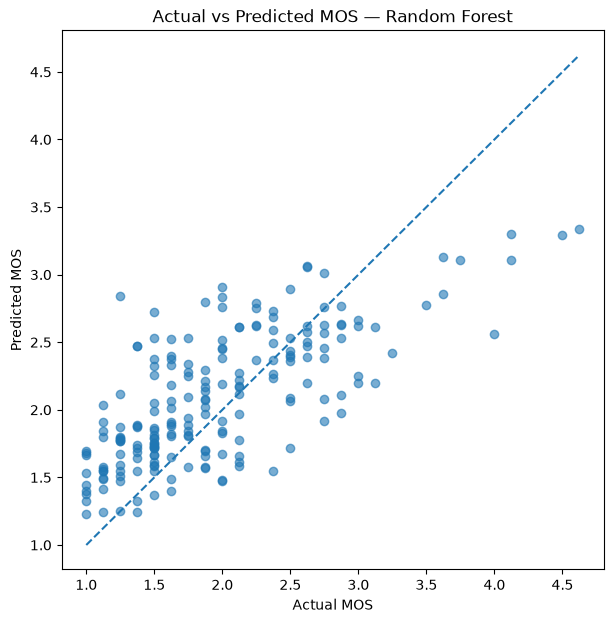

In [23]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.xlabel("Actual MOS")
plt.ylabel("Predicted MOS")
plt.title(f"Actual vs Predicted MOS — {best_model_name}")

min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.show()

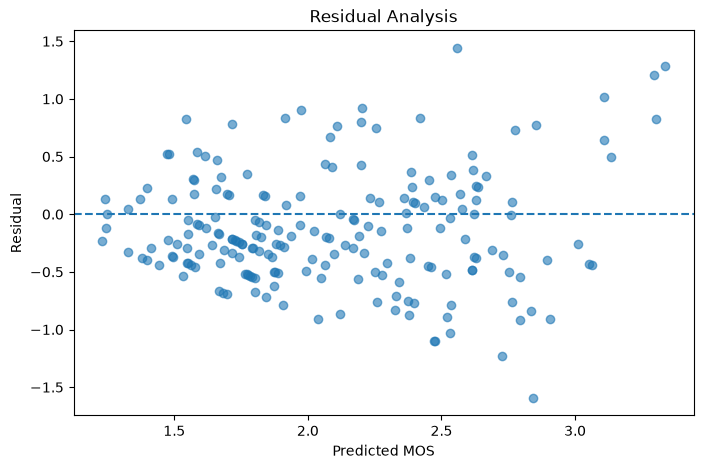

In [24]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted MOS")
plt.ylabel("Residual")
plt.title("Residual Analysis")

plt.show()

In [25]:
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())
print("Residual minimum:", residuals.min())
print("Residual maximum:", residuals.max())

Residual mean: -0.13641250000000002
Residual std: 0.4940280419036817
Residual minimum: -1.59375
Residual maximum: 1.4412500000000001


In [26]:
MODEL_DIR = "../models/classical"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

In [27]:
MODEL_PATH = (
    f"{MODEL_DIR}/voiceiq_{best_model_name.lower().replace(' ', '_')}.joblib"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: ../models/classical/voiceiq_random_forest.joblib


In [28]:
MODEL_PATH = (
    f"{MODEL_DIR}/voiceiq_{best_model_name.lower().replace(' ', '_')}.joblib"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: ../models/classical/voiceiq_random_forest.joblib
